In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/shivamb/netflix-shows/netflix_titles.csv


In [2]:
import pandas as pd
import numpy as np

# Dataset load karo
df = pd.read_csv("/kaggle/input/datasets/shivamb/netflix-shows/netflix_titles.csv")

# Pehli 5 rows dekho
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
print("Shape:", df.shape)
df.info()

Shape: (8807, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [4]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [5]:
# Missing values check karo har column mein
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [6]:
# Duplicate rows check karo
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [7]:
# director, cast, country mein missing values ko "Unknown" se fill karo
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

# baaki jo columns mein kam missing values hain, unki rows drop kar do
df = df.dropna(subset=['date_added', 'rating', 'duration'])

# check karo ab missing values kitni bachi
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [8]:
# Total Movies vs TV Shows kitne hain
print(df['type'].value_counts())

type
Movie      6126
TV Show    2664
Name: count, dtype: int64


In [9]:
# Konse saal (year) mein sabse zyada content release hua
print(df['release_year'].value_counts().head(10))

release_year
2018    1146
2017    1030
2019    1030
2020     953
2016     901
2021     592
2015     555
2014     352
2013     286
2012     236
Name: count, dtype: int64


In [10]:
# Average release year (NumPy se)
print("Average Release Year:", np.mean(df['release_year']))

Average Release Year: 2014.183162684869


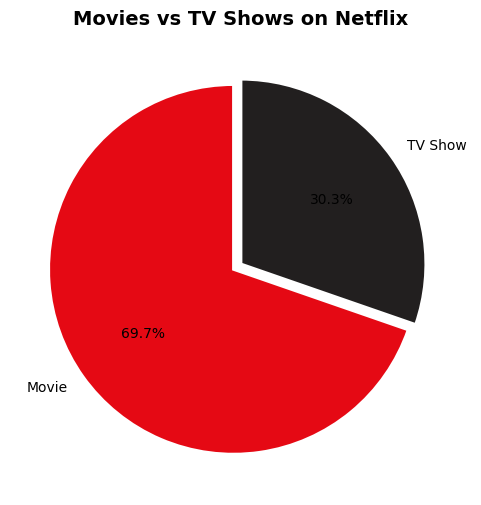

In [11]:
import matplotlib.pyplot as plt

type_counts = df['type'].value_counts()

plt.figure(figsize=(7, 6))
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%',
        colors=['#E50914', '#221f1f'], startangle=90,
        explode=(0.05, 0), wedgeprops={'edgecolor': 'white', 'linewidth': 2})
plt.title('Movies vs TV Shows on Netflix', fontsize=14, fontweight='bold')
plt.show()

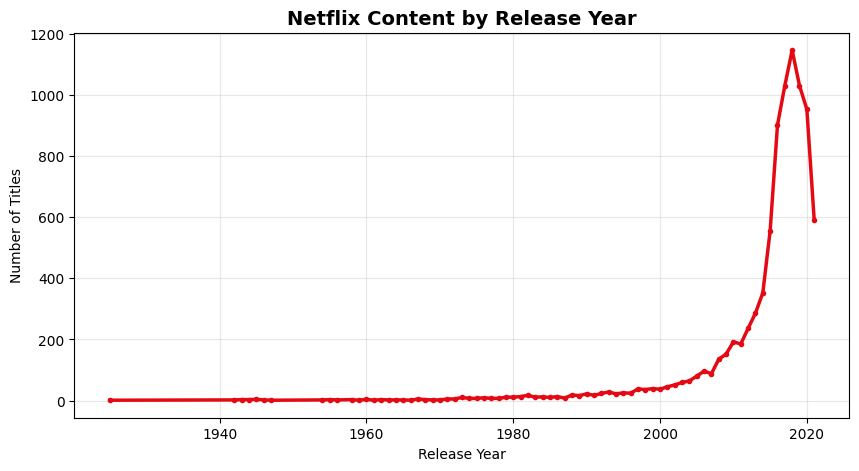

In [12]:
year_counts = df['release_year'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.plot(year_counts.index, year_counts.values, color='#E50914', linewidth=2.5, marker='o', markersize=3)
plt.title('Netflix Content by Release Year', fontsize=14, fontweight='bold')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.grid(alpha=0.3)
plt.show()

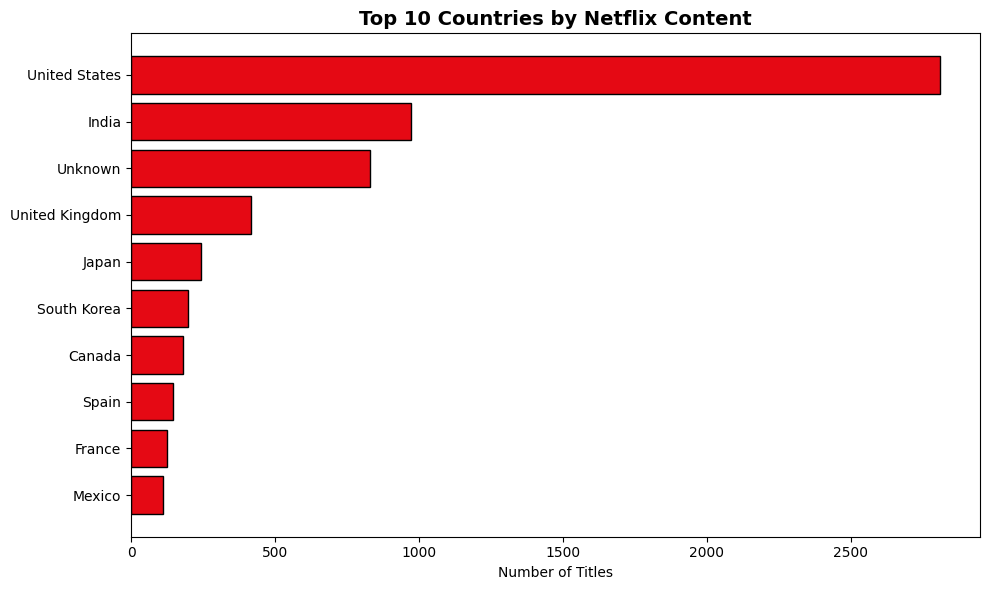

In [13]:
top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_countries.index[::-1], top_countries.values[::-1], color='#E50914', edgecolor='black')
plt.title('Top 10 Countries by Netflix Content', fontsize=14, fontweight='bold')
plt.xlabel('Number of Titles')
plt.tight_layout()
plt.show()

In [14]:
# Genres ko split karke count karo (kyunki har title ke multiple genres hote hain)
from collections import Counter

all_genres = df['listed_in'].str.split(', ').sum()
genre_counts = Counter(all_genres)
top_genres = pd.Series(genre_counts).sort_values(ascending=False).head(10)

print(top_genres)

International Movies        2752
Dramas                      2426
Comedies                    1674
International TV Shows      1349
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
dtype: int64


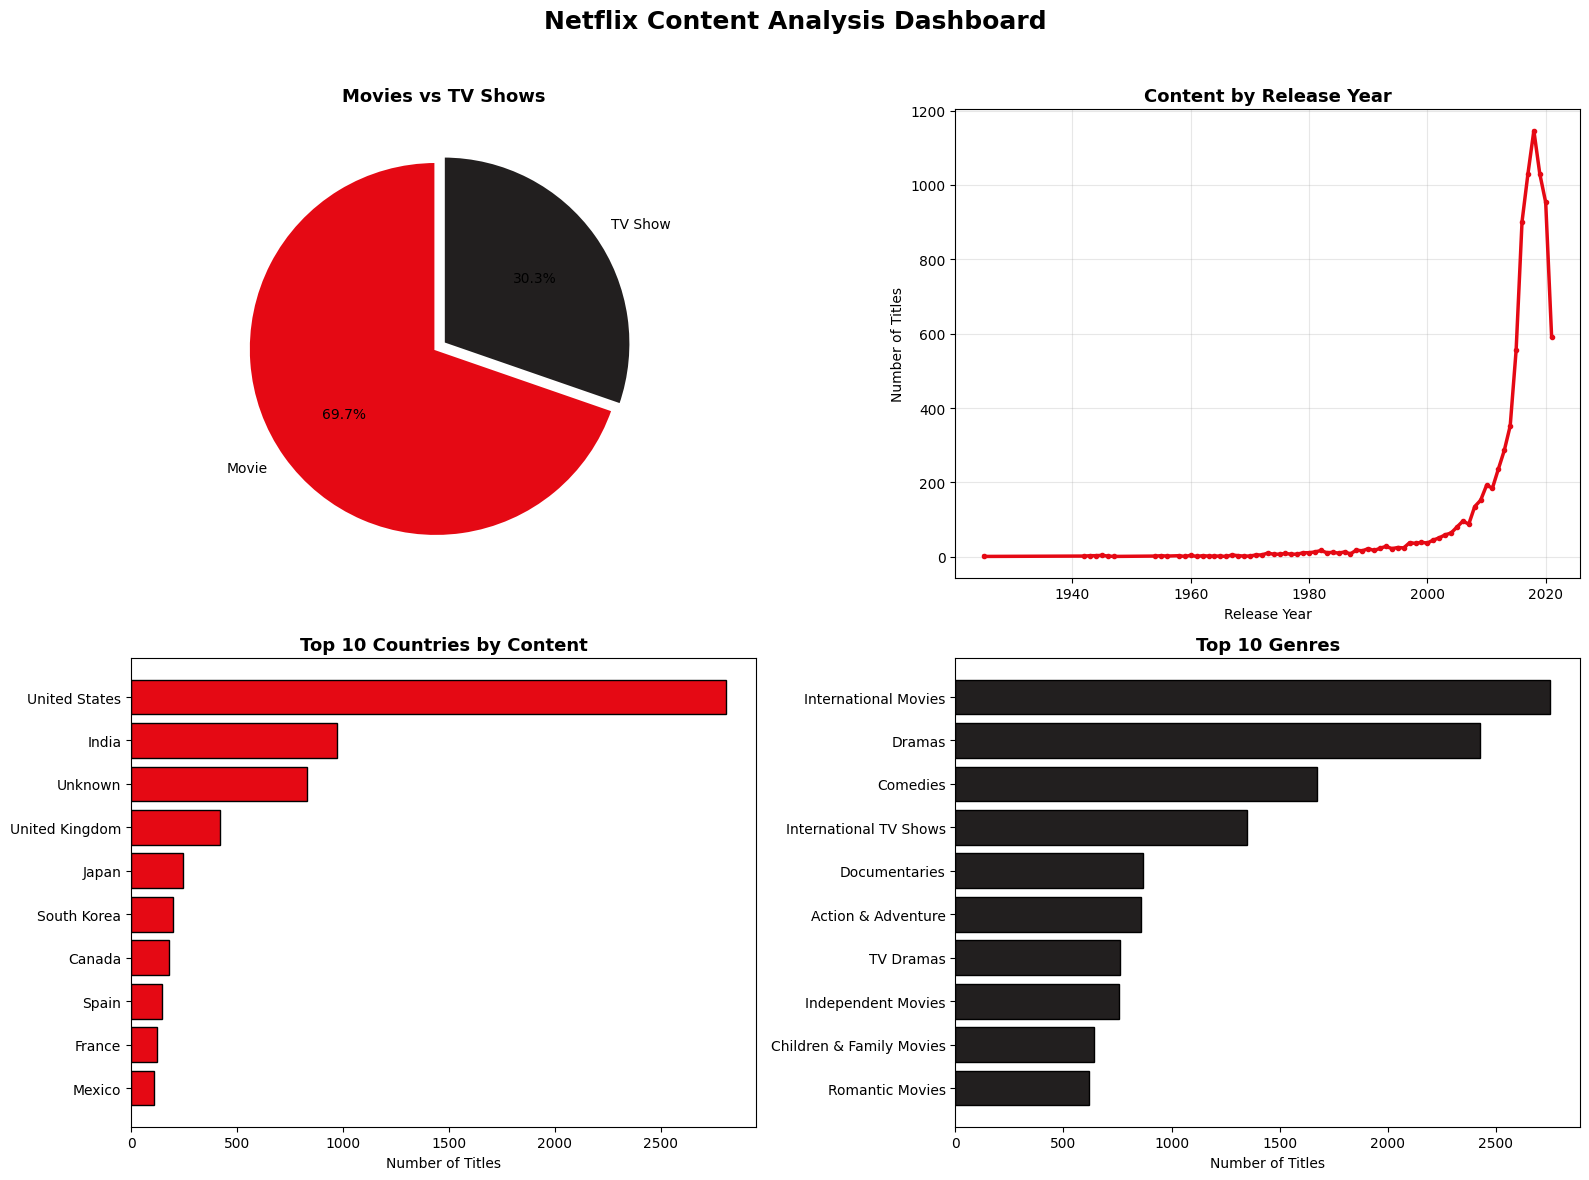

In [15]:
fig, axs = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Netflix Content Analysis Dashboard', fontsize=18, fontweight='bold', y=0.98)

# 1. Movies vs TV Shows (Pie Chart)
type_counts = df['type'].value_counts()
axs[0,0].pie(type_counts, labels=type_counts.index, autopct='%1.1f%%',
             colors=['#E50914', '#221f1f'], startangle=90,
             explode=(0.05, 0), wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axs[0,0].set_title('Movies vs TV Shows', fontsize=13, fontweight='bold')

# 2. Content by Release Year (Line Chart)
year_counts = df['release_year'].value_counts().sort_index()
axs[0,1].plot(year_counts.index, year_counts.values, color='#E50914',
              linewidth=2.5, marker='o', markersize=3)
axs[0,1].set_title('Content by Release Year', fontsize=13, fontweight='bold')
axs[0,1].set_xlabel('Release Year')
axs[0,1].set_ylabel('Number of Titles')
axs[0,1].grid(alpha=0.3)

# 3. Top 10 Countries (Horizontal Bar)
top_countries = df['country'].value_counts().head(10)
axs[1,0].barh(top_countries.index[::-1], top_countries.values[::-1],
              color='#E50914', edgecolor='black')
axs[1,0].set_title('Top 10 Countries by Content', fontsize=13, fontweight='bold')
axs[1,0].set_xlabel('Number of Titles')

# 4. Top 10 Genres (Horizontal Bar)
axs[1,1].barh(top_genres.index[::-1], top_genres.values[::-1],
              color='#221f1f', edgecolor='black')
axs[1,1].set_title('Top 10 Genres', fontsize=13, fontweight='bold')
axs[1,1].set_xlabel('Number of Titles')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('netflix_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

## Key Findings

- **Content Type:** Netflix's library is dominated by movies (69.7%), with TV shows making up only 30.3% of total titles.
- **Growth Trend:** Content addition peaked between 2016-2019, with 2018 being the highest year. The apparent decline after 2020 is likely due to incomplete data collection for recent years rather than an actual drop in content production.
- **Geographic Distribution:** The United States leads content production by a wide margin, reflecting Netflix's origins and continued dominance in the US market.
- **Genre Preferences:** International Movies and Dramas are the most common genres, followed by Comedies and International TV Shows — indicating a strong focus on global and dramatic content.
- **Data Quality:** A significant portion of records had missing values in `director`, `cast`, and `country` fields, which were handled by labeling them as "Unknown" to preserve data integrity without losing valuable records.

## Conclusion

This analysis provides a high-level overview of Netflix's content library as of the dataset's collection date. The platform shows a clear historical preference for movies over TV shows, with the United States as the primary content contributor. Future analysis could explore duration trends, rating distributions, or genre popularity over time for deeper insights.